<a href="https://colab.research.google.com/github/de-fernandez/CPE-313-CPE32S3/blob/main/Don%20Eleazar%20T.%20Fernandez%2C%20CPE32S3%2C%20CPE%20313%20(Assessment%20Task%204.1%20Supplementary%20Activity%20on%20Transfer%20Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assessment Task 4.1 Supplementary Activity on Transfer Learning

Instruction:

- Perform Transfer Learning on PyTorch, afterwards perform transfer learning (either fine tuning or a feature extraction) on your chosen dataset.
- Take note of your experiment.
- Reach at least 95% test accuracy.

In [1]:
 !nvidia-smi

Mon Feb 23 14:09:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             16W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

1. Choose a pretrained model.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

data_dir = '/content/drive/MyDrive/CPE313/images'

# Load FULL dataset
full_dataset = datasets.ImageFolder(data_dir)

# Split 80% train / 20% val
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# ⚠️ Apply transforms separately
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# Dataloaders
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=32, shuffle=False)
}

dataset_sizes = {
    'train': len(train_dataset),
    'val': len(val_dataset)
}

class_names = full_dataset.classes

print("Classes:", class_names)
print("Train size:", dataset_sizes['train'])
print("Val size:", dataset_sizes['val'])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Classes: ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']
Train size: 287
Val size: 72
Using device: cuda


2. Finetune on your dataset from the previous activity.

In [5]:
def train_model_googlenet(model, dataloaders, dataset_sizes, device, criterion, optimizer, scheduler=None, num_epochs=25):
    since = time.time()

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_googlenet_params.pt')
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)

                        # Handle GoogLeNet outputs with optional auxiliary logits
                        if model.aux_logits and phase == 'train':
                            # outputs is a tuple: (main_logits, aux_logits)
                            main_logits, aux_logits = outputs
                            loss_main = criterion(main_logits, labels)
                            loss_aux = criterion(aux_logits, labels)
                            loss = loss_main + 0.4 * loss_aux
                            logits = main_logits
                        else:
                            # aux_logits disabled or in eval
                            logits = outputs
                            loss = criterion(logits, labels)

                        _, preds = torch.max(logits, 1)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                if phase == 'train' and scheduler is not None:
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # Save best weights
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:.4f}')

        # Load best weights
        model.load_state_dict(torch.load(best_model_params_path))

    return model

In [6]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(10, 6))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                images_so_far += 1

                ax = plt.subplot(num_images // 2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')

                # Move to CPU
                img = inputs[j].cpu()

                # Convert from (C,H,W) to (H,W,C)
                img = img.permute(1, 2, 0).numpy()

                # Undo normalization
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                plt.imshow(img)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return

        model.train(mode=was_training)

In [7]:
model = models.googlenet(pretrained=True)

num_classes = 9

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

if model.aux_logits:
    num_ftrs_aux = model.AuxLogits.fc.in_features
    model.AuxLogits.fc = nn.Linear(num_ftrs_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


3. Evaluate the performance of the previous model to this finetuned model.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [8]:
model = train_model_googlenet(
    model=model,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler,
    num_epochs=8
)


Epoch 0/7
----------
train Loss: 2.0360 Acc: 0.2613
val Loss: 1.3181 Acc: 0.8056

Epoch 1/7
----------
train Loss: 0.9357 Acc: 0.8362
val Loss: 0.5211 Acc: 0.8333

Epoch 2/7
----------
train Loss: 0.3403 Acc: 0.9373
val Loss: 0.3177 Acc: 0.9167

Epoch 3/7
----------
train Loss: 0.1002 Acc: 0.9895
val Loss: 0.2583 Acc: 0.9306

Epoch 4/7
----------
train Loss: 0.0449 Acc: 1.0000
val Loss: 0.2705 Acc: 0.9028

Epoch 5/7
----------
train Loss: 0.0220 Acc: 1.0000
val Loss: 0.2398 Acc: 0.9306

Epoch 6/7
----------
train Loss: 0.0183 Acc: 1.0000
val Loss: 0.2239 Acc: 0.9583

Epoch 7/7
----------
train Loss: 0.0138 Acc: 1.0000
val Loss: 0.2228 Acc: 0.9583

Training complete in 2m 58s
Best val Acc: 0.9583


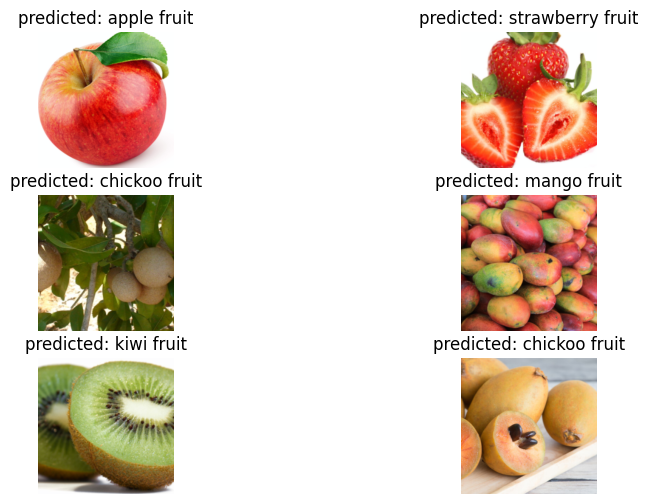

In [9]:
visualize_model(model)

plt.ioff()
plt.show()

**Analysis:** I used a GoogLeNet model to train 9 different types of fruits. The model first used what it already knew about general images, then learned the details of the fruit photos. By carefully adjusting how it learned over time, the model got better and better. In the end, it became very accurate and could correctly identify fruits about 95.8% of the time.